In [9]:
import torch
torch_version = torch.__version__.split('+')[0]
scatter_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
sparse_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
!pip install torch-scatter -f $scatter_src
!pip install torch-sparse -f $sparse_src
!pip install torch-geometric
!pip install pyg-lib
!pip install scikit-learn

Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2.html


ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib


In [10]:
import torch
print(torch.__version__)
import torch_geometric
print(torch_geometric.__version__)

2.2.2+cpu
2.6.1


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from collections import defaultdict
import copy
from sklearn.model_selection import train_test_split
from torch_geometric.data import HeteroData
from torch_geometric.utils import dropout_edge, negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import trange
import time
import matplotlib.pyplot as plt
import requests
import zipfile
import io
import os
import pandas as pd

In [12]:
# ============================================
# GR-MC: Graph Neural Network Recommendation with 
# Multi-scale Attention and Contrastive Learning
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import softmax
from torch_scatter import scatter_add
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {seed}")


class MultiScaleLargeKernelAttention(nn.Module):
    """
    MLKA for GR-MC

    Implements:

    LKA(X)  = Large receptive field branch
    MSM(X)  = Multi-scale feature extraction
    GA(X)   = Gated aggregation

    Paper-inspired graph version.
    """

    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        # Learnable scale attention
        self.scale_attention = nn.Parameter(
            torch.zeros(3)
        )

        self.gate = nn.Sequential(
                nn.Linear(hidden_size * 3,
                hidden_size),
                nn.Sigmoid()
        )

        self.output_proj = nn.Linear(
            hidden_size,
            hidden_size
        )

    def forward(self, x,edge_index):

        # --------------------------
        # Multi-scale features
        # --------------------------

        
        src = edge_index[0]
        dst = edge_index[1]

        num_nodes = x.size(0)
        
        
        ###################################
        # 1-hop
        ###################################

        hop1 = scatter_add(
            x[src],
            dst,
            dim=0,
            dim_size=num_nodes
        )

        ###################################
        # 2-hop
        ###################################

        hop2 = scatter_add(
            hop1[src],
            dst,
            dim=0,
            dim_size=num_nodes
        )

        ###################################
        # 3-hop
        ###################################

        hop3 = scatter_add(
            hop2[src],
            dst,
            dim=0,
            dim_size=num_nodes
        )

        ###################################
        # Multi-scale attention
        ###################################

        weights = F.softmax(
            self.scale_attention,
            dim=0
        )
        
        hop1 = F.normalize(hop1, p=2, dim=1)
        hop2 = F.normalize(hop2, p=2, dim=1)
        hop3 = F.normalize(hop3, p=2, dim=1)

        multi_scale = (
            weights[0] * hop1 +
            weights[1] * hop2 +
            weights[2] * hop3
        )

        ###################################
        # Gate
        ###################################

        concat = torch.cat(
            [hop1, hop2, hop3],
            dim=-1
        )

        gate = self.gate(concat)

        output = (
            gate * multi_scale +
            (1 - gate) * x
        )

        output = self.output_proj(
            output
        )

        return output
     
        

class GraphStructureAttentionUnit(nn.Module):
    """
    GSAU from GR-MC paper

    Implements:

    Eq.(13) Attention-based neighbor aggregation

    Eq.(14) Structure-aware propagation
            A_ui * d_i * pi_ui

    Eq.(15) High-order neighbor aggregation

    """

    def __init__(self, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size

        # Query Key Value projections
        self.query_proj = nn.Linear(hidden_size, hidden_size)
        self.key_proj = nn.Linear(hidden_size, hidden_size)
        self.value_proj = nn.Linear(hidden_size, hidden_size)

        self.leaky_relu = nn.LeakyReLU(0.2)

        self.scale = hidden_size ** -0.5

        # Learnable weight for second-order propagation
        self.second_order_weight = nn.Parameter(
            torch.tensor(0.1)
        )

        self.output_proj = nn.Linear(
            hidden_size,
            hidden_size
        )

        self.layer_norm = nn.LayerNorm(hidden_size)

    def forward(
        self,
        query_features,
        key_features,
        edge_index):

        x = query_features

        src = edge_index[0]
        dst = edge_index[1]

        num_nodes = x.size(0)

        # Query
        Q = self.query_proj(query_features)

        # Key
        K = self.key_proj(key_features)

        # Value
        V = self.value_proj(key_features)

        # ====================================================
        # Eq.(13)
        # Attention scores
        # ====================================================

        q_dst = Q[dst]
        k_src = K[src]

        attn_scores = (
            (q_dst * k_src).sum(dim=-1)
            * self.scale
        )

        attn_scores = self.leaky_relu(
            attn_scores
        )

        # ====================================================
        # Softmax over neighbors
        # ====================================================

        attn_weights = softmax(
            attn_scores,
            dst
        )

        # ====================================================
        # Eq.(14)
        # Degree-aware propagation
        # ====================================================

        degree = scatter_add(
            torch.ones_like(src, dtype=torch.float),
            src,
            dim=0,
            dim_size=num_nodes
        )

        structure_weight = (
            attn_weights *
            degree[src].float()
            /
            (degree.max() + 1e-8)
        )

        messages = (
            V[src]
            * structure_weight.unsqueeze(-1)
        )

        first_order = scatter_add(
            messages,
            dst,
            dim=0,
            dim_size=num_nodes
        )

        # ====================================================
        # Eq.(15)
        # Second-order propagation
        # ====================================================

        second_order = scatter_add(
            first_order[src],
            dst,
            dim=0,
            dim_size=num_nodes
        )

        # ====================================================
        # Combine first and second order
        # ====================================================

        aggregated = (
            first_order +
            self.second_order_weight *
            second_order
        )

        # ====================================================
        # Residual update
        # X = X + λ2 f6(M)
        # ====================================================

        output = self.output_proj(aggregated)

        output = self.layer_norm(output)

        return output

    
class MAEPLayer(nn.Module):
    """
    Multi-Scale Attention Embedding Propagation Layer (MAEP)

    Paper Equations:

    N = LN(X)
    X = X + λ1 f3(MLKA(f1(N)) ⊗ f2(N))

    N = LN(X)
    X = X + λ2 f6(GSAU(f4(N), f5(N)))

    """

    def __init__(self, hidden_size):

        super().__init__()

        self.hidden_size = hidden_size

        # LayerNorms
        self.layer_norm1 = nn.LayerNorm(hidden_size)
        self.layer_norm2 = nn.LayerNorm(hidden_size)

        # Pointwise projections
        self.f1 = nn.Linear(hidden_size, hidden_size)
        self.f2 = nn.Linear(hidden_size, hidden_size)
        self.f3 = nn.Linear(hidden_size, hidden_size)

        self.f4 = nn.Linear(hidden_size, hidden_size)
        self.f5 = nn.Linear(hidden_size, hidden_size)
        self.f6 = nn.Linear(hidden_size, hidden_size)

        # MLKA
        self.mlka = MultiScaleLargeKernelAttention(
            hidden_size
        )

        # GSAU
        self.gsau = GraphStructureAttentionUnit(
            hidden_size
        )

        # Learnable scaling factors
        self.lambda1 = nn.Parameter(
            torch.tensor(0.5)
        )

        self.lambda2 = nn.Parameter(
            torch.tensor(0.5)
        )

    def forward(self, x, edge_index):

        ####################################################
        # Equation (8)
        ####################################################

        n1 = self.layer_norm1(x)

        h1 = self.f1(n1)

        h2 = self.f2(n1)

               
        mlka_out = self.mlka(h1,edge_index)

        # element-wise multiplication
        z = mlka_out * h2

        mlka_update = self.f3(z)

        x = x + self.lambda1 * mlka_update

        ####################################################
        # Equation (9)
        ####################################################

        n2 = self.layer_norm2(x)

        query_features = self.f4(n2)

        key_features = self.f5(n2)

        gsau_out = self.gsau(
            query_features,
            key_features,
            edge_index
        )

        gsau_update = self.f6(gsau_out)

        x = x + self.lambda2 * gsau_update

        return x

class GRMC(nn.Module):

    def __init__(
            self,
            num_users,
            num_items,
            hidden_size=128,
            num_layers=3,
            edge_dropout=0.1,
            temperature=0.2,
            contrastive_weight=0.05,
            reg_weight=1e-6):

        super().__init__()

        self.num_users = num_users
        self.num_items = num_items

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.temperature = temperature
        self.contrastive_weight = contrastive_weight
        self.reg_weight = reg_weight

        self.edge_dropout_prob = edge_dropout

        ####################################################
        # Embeddings
        ####################################################

        self.user_embeddings = nn.Embedding(
            num_users,
            hidden_size
        )

        self.item_embeddings = nn.Embedding(
            num_items,
            hidden_size
        )

        nn.init.xavier_uniform_(
            self.user_embeddings.weight
        )

        nn.init.xavier_uniform_(
            self.item_embeddings.weight
        )

        ####################################################
        # MAEP Layers
        ####################################################

        self.maep_layers = nn.ModuleList(
            [
                MAEPLayer(hidden_size)
                for _ in range(num_layers)
            ]
        )

    ########################################################
    # User-Focused Edge Dropout
    ########################################################

    def edge_dropout(
            self,
            edge_index,
            p=None):

        if p is None:
            p = self.edge_dropout_prob

        if (not self.training) or p == 0:
            return edge_index

        src = edge_index[0]

        user_mask = src < self.num_users

        degrees = torch.bincount(
            src[user_mask],
            minlength=self.num_users
        )

        keep_mask = torch.ones(
            edge_index.size(1),
            dtype=torch.bool,
            device=edge_index.device
        )

        user_edges = torch.where(user_mask)[0]

        edge_probs = (
            p *
            degrees[src[user_mask]].float()
            /
            (
                degrees.max().float()
                + 1e-8
            )
        )

        edge_probs = torch.clamp(
            edge_probs,
            max=0.5
        )

        random_mask = (
            torch.rand_like(edge_probs)
            > edge_probs
        )

        keep_mask[user_edges] = random_mask

        return edge_index[:, keep_mask]

    ########################################################
    # Graph Augmentation
    ########################################################

    def generate_views(
            self,
            edge_index):

        view1 = self.edge_dropout(
            edge_index
        )

        view2 = self.edge_dropout(
            edge_index
        )

        return view1, view2

    ########################################################
    # MAEP Propagation
    ########################################################

    def propagate(
            self,
            user_emb,
            item_emb,
            edge_index):

        x = torch.cat(
            [user_emb, item_emb],
            dim=0
        )

        embeddings = [x]

        for layer in self.maep_layers:

            x = layer(
                x,
                edge_index
            )

            embeddings.append(x)

        ####################################################
        # Uniform fusion
        ####################################################

        final_embedding = torch.stack(
            embeddings,
            dim=0
        ).mean(dim=0)

        user_embedding = final_embedding[
            :self.num_users
        ]

        item_embedding = final_embedding[
            self.num_users:
        ]

        return (
            user_embedding,
            item_embedding
        )

    ########################################################
    # Forward
    ########################################################

    def forward(
            self,
            edge_index,
            return_views=False):

        user_emb = self.user_embeddings.weight

        item_emb = self.item_embeddings.weight

        if self.training and return_views:

            view1, view2 = self.generate_views(
                edge_index
            )

            emb1 = self.propagate(
                user_emb,
                item_emb,
                view1
            )

            emb2 = self.propagate(
                user_emb,
                item_emb,
                view2
            )

            return emb1, emb2

        return self.propagate(
            user_emb,
            item_emb,
            edge_index
        )

    ########################################################
    # Prediction
    ########################################################

    def predict(
            self,
            user_emb,
            item_emb,
            user_ids,
            item_ids):

        u = user_emb[user_ids]

        i = item_emb[item_ids]

        return torch.sum(
            u * i,
            dim=-1
        )

    ########################################################
    # InfoNCE Loss
    ########################################################

    def contrastive_loss(
        self,
        user_emb1,
        user_emb2,
        sample_size=4096):

        num_users = user_emb1.size(0)

        if num_users > sample_size:
                  
            idx = torch.randperm(
                  num_users,
                  device=user_emb1.device
            )[:sample_size]

            user_emb1 = user_emb1[idx]
            user_emb2 = user_emb2[idx]

        z1 = F.normalize(user_emb1, dim=1)
        z2 = F.normalize(user_emb2, dim=1)

        logits = torch.mm(
            z1,
            z2.t()
        )

        logits /= self.temperature

        labels = torch.arange(
            z1.size(0),
            device=z1.device
        )

        return F.cross_entropy(
            logits,
            labels
        )

    ########################################################
    # BPR Loss
    ########################################################

    def bpr_loss(
            self,
            user_emb,
            item_emb,
            pos_edge_index,
            neg_edge_index):

        pos_scores = self.predict(
            user_emb,
            item_emb,
            pos_edge_index[0],
            pos_edge_index[1]
        )

        neg_scores = self.predict(
            user_emb,
            item_emb,
            neg_edge_index[0],
            neg_edge_index[1]
        )

        bpr = -torch.log(
            torch.sigmoid(
                pos_scores -
                neg_scores
            )
            + 1e-12
        ).mean()

        reg_loss = (
            self.user_embeddings.weight.norm(2).pow(2)
            +
            self.item_embeddings.weight.norm(2).pow(2)
        )

        reg_loss = (
            self.reg_weight *
            reg_loss
        )

        return bpr + reg_loss

    ########################################################
    # Total Loss
    ########################################################

    def total_loss(
            self,
            pos_edge_index,
            neg_edge_index,
            edge_index):

        (
            (user_emb1, item_emb1),
            (user_emb2, item_emb2)
        ) = self.forward(
            edge_index,
            return_views=True
        )

        bpr = self.bpr_loss(
            user_emb1,
            item_emb1,
            pos_edge_index,
            neg_edge_index
        )

        ssl = self.contrastive_loss(
            user_emb1,
            user_emb2
        )

        total = (
            bpr
            +
            self.contrastive_weight
            * ssl
        )

        return total, bpr, ssl


class GRMCTrainer:

    def __init__(
            self,
            model,
            learning_rate=1e-4,
            weight_decay=1e-5,
            patience=50,
            device='cpu'):

        self.model = model.to(device)

        self.device = device

        self.patience = patience

        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

        self.scheduler = (
            torch.optim.lr_scheduler.CosineAnnealingLR(
                self.optimizer,
                T_max=100,
                eta_min=1e-6
            )
        )

        self.best_metric = -float('inf')
        self.early_stop_counter = 0

    ####################################################
    # TRAIN ONE EPOCH
    ####################################################

    def train_epoch(
            self,
            edge_index,
            pos_edge_index,
            neg_edge_index):

        self.model.train()

        self.optimizer.zero_grad()

        total_loss, bpr_loss, ssl_loss = (
            self.model.total_loss(
                pos_edge_index,
                neg_edge_index,
                edge_index
            )
        )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            self.model.parameters(),
            max_norm=1.0
        )

        self.optimizer.step()

        return {
            'total_loss': total_loss.item(),
            'bpr_loss': bpr_loss.item(),
            'ssl_loss': ssl_loss.item()
        }

    ####################################################
    # STEP LR SCHEDULER
    ####################################################

    def scheduler_step(self):

        self.scheduler.step()

    ####################################################
    # LINK PREDICTION EVALUATION
    ####################################################

    @torch.no_grad()
    def evaluate_link_prediction(
            self,
            edge_index,
            eval_edges,
            eval_labels):

        self.model.eval()

        user_emb, item_emb = self.model(
            edge_index,
            return_views=False
        )

        scores = self.model.predict(
            user_emb,
            item_emb,
            eval_edges[0],
            eval_edges[1]
        )

        scores = torch.sigmoid(scores)

        scores_np = scores.cpu().numpy()

        labels_np = eval_labels.cpu().numpy()

        auc = roc_auc_score(
            labels_np,
            scores_np
        )

        ap = average_precision_score(
            labels_np,
            scores_np
        )

        return {
            "AUC": auc,
            "AP": ap
        }

    ####################################################
    # RECALL@K / NDCG@K
    ####################################################

    @torch.no_grad()
    def evaluate_recommendation_metrics(
            self,
            edge_index,
            test_edges,
            test_labels,
            k_list=[5, 10, 20]):

        self.model.eval()

        user_emb, item_emb = self.model(
            edge_index,
            return_views=False
        )

        positive_edges = (
            test_edges[:,
            test_labels == 1]
        )

        if positive_edges.size(1) == 0:

            results = {}

            for k in k_list:
                results[f"Recall@{k}"] = 0.0
                results[f"NDCG@{k}"] = 0.0
                results[f"HitRatio@{k}"] = 0.0
            results["MRR"] = 0.0    

            return results

        all_items = np.arange(
            self.model.num_items
        )
        
        user_positive_items = {}

        src = edge_index[0].cpu().numpy()
        dst = edge_index[1].cpu().numpy()

        for u, m in zip(src, dst):

            if u not in user_positive_items:
                user_positive_items[u] = set()

            user_positive_items[u].add(m)
       

        recall_scores = {
            k: [] for k in k_list
        }

        ndcg_scores = {
            k: [] for k in k_list
        }
        
        hit_ratio_scores = {
            k: [] for k in k_list
        }
        
        mrr_scores = []

        max_eval = min(
            5000,
            positive_edges.size(1)
        )

        if positive_edges.size(1) > max_eval:

            idx = np.random.choice(
                positive_edges.size(1),
                max_eval,
                replace=False
            )

            positive_edges = (
                positive_edges[:, idx]
            )

        for idx in range(
                positive_edges.size(1)):

            user_id = (
                positive_edges[0, idx]
                .item()
            )

            pos_item = (
                positive_edges[1, idx]
                .item()
            )

            user_seen = user_positive_items.get(
                user_id,
                set()
            ).copy()

            user_seen.discard(pos_item)

            candidate_pool = np.array(
                list(
                set(all_items) - user_seen
                )
             )

            if len(candidate_pool) < 99:
                continue

            negative_items = np.random.choice(
            candidate_pool,
            size=99,
            replace=False
            )

            candidate_items = (
                np.append(
                    negative_items,
                    pos_item
                )
            )

            user_vector = (
                user_emb[user_id]
                .unsqueeze(0)
            )

            item_vectors = (
                item_emb[
                    torch.LongTensor(
                        candidate_items
                    ).to(self.device)
                ]
            )

            scores = (
                user_vector *
                item_vectors
            ).sum(dim=1)

            scores = (
                scores
                .cpu()
                .numpy()
            )

            ranking = (
                np.argsort(scores)[::-1]
            )

            ranked_items = (
                candidate_items[
                    ranking
                ]
            )

            rank = (
                np.where(
                    ranked_items ==
                    pos_item
                )[0][0] + 1
            )
            
            mrr_scores.append(1.0 / rank)

            for k in k_list:

                if rank <= k:

                    recall_scores[k].append(1)
                    hit_ratio_scores[k].append(1) 

                    ndcg_scores[k].append(1 /np.log2(rank + 1))

                else:

                    recall_scores[k].append(0)
                    hit_ratio_scores[k].append(0)
                    ndcg_scores[k].append(0)

        results = {}

        for k in k_list:

            results[f"Recall@{k}"] = (
                np.mean(
                    recall_scores[k]
                )
            )
            
            results[f"HitRatio@{k}"] = (
                np.mean(
                    hit_ratio_scores[k]
                )
            )

            results[f"NDCG@{k}"] = (
                np.mean(
                    ndcg_scores[k]
                )
            )
         # Add MRR to results
        results["MRR"] = np.mean(mrr_scores) if len(mrr_scores) > 0 else 0.0   

        return results

    ####################################################
    # EARLY STOPPING
    ####################################################

    def early_stopping(
            self,
            current_metric):

        if current_metric > self.best_metric:
            
            torch.save(self.model.state_dict(),"best_grmc.pt")

            self.best_metric = current_metric

            self.early_stop_counter = 0

            return False

        self.early_stop_counter += 1

        if self.early_stop_counter >= self.patience:

            return True

        return False

    ####################################################
    # FULL TRAINING LOOP
    ####################################################

    def fit(
            self,
            edge_index,
            pos_edge_index,
            neg_edge_index,
            val_edges,
            val_labels,
            epochs=300):

        history = []

        for epoch in range(epochs):

            train_metrics = (
                self.train_epoch(
                    edge_index,
                    pos_edge_index,
                    neg_edge_index
                )
            )

            val_metrics = (
                self.evaluate_link_prediction(
                    edge_index,
                    val_edges,
                    val_labels
                )
            )

            self.scheduler_step()

            recommend_metrics = (
                self.evaluate_recommendation_metrics(
                    edge_index,
                    val_edges,
                    val_labels,
                    [20]
                )
            )

            current_metric = (
                recommend_metrics["Recall@20"]
            )

            stop = (
                self.early_stopping(
                current_metric
                )
            )

            result = {
                "epoch": epoch + 1,
                **train_metrics,
                **val_metrics,
                **recommend_metrics
            }

            history.append(result)

            print(
                f"Epoch {epoch+1:03d} | "
                f"Loss={train_metrics['total_loss']:.4f} | "
                f"AUC={val_metrics['AUC']:.4f} | "
                f"AP={val_metrics['AP']:.4f}"
            )

            if stop:

                print(
                    f"Early stopping "
                    f"at epoch {epoch+1}"
                )

                break

        return history

Random seed set to 42


In [13]:
def prepare_gr_mc_data(data, val_ratio=0.05, test_ratio=0.05):
    """Prepare data for GR-MC training on Gowalla"""

    # Gowalla graph
    edge_index = data.edge_index

    num_edges = edge_index.size(1)
    perm = torch.randperm(num_edges)

    num_val = int(num_edges * val_ratio)
    num_test = int(num_edges * test_ratio)
    num_train = num_edges - num_val - num_test

    train_idx = perm[:num_train]
    val_idx = perm[num_train:num_train + num_val]
    test_idx = perm[num_train + num_val:]

    train_pos_edge_index = edge_index[:, train_idx]
    val_pos_edge_index = edge_index[:, val_idx]
    test_pos_edge_index = edge_index[:, test_idx]

    num_users = data.num_users
    num_items = data.num_items

    positive_set = {
        (u, i)
        for u, i in zip(
            edge_index[0].cpu().numpy(),
            edge_index[1].cpu().numpy()
        )
    }

    def sample_negatives(num_samples):

        neg_edges = []

        while len(neg_edges) < num_samples:

            batch_size = min(
                (num_samples - len(neg_edges)) * 2,
                100000
            )

            users = torch.randint(
                0,
                num_users,
                (batch_size,)
            )

            items = torch.randint(
                0,
                num_items,
                (batch_size,)
            )

            for u, i in zip(
                users.tolist(),
                items.tolist()
            ):

                if (u, i) not in positive_set:

                    neg_edges.append([u, i])

                    if len(neg_edges) >= num_samples:
                        break

        return torch.tensor(
            neg_edges,
            dtype=torch.long
        ).t()
  

    max_train_neg = min(train_pos_edge_index.size(1),150000)
    train_pos_edge_index = train_pos_edge_index[:, :max_train_neg]
    train_neg = sample_negatives(max_train_neg)
    
    val_neg = sample_negatives(val_pos_edge_index.size(1))
    test_neg = sample_negatives(test_pos_edge_index.size(1))

    data.train_pos_edge_index = train_pos_edge_index
    data.train_neg_edge_index = train_neg

    data.val_edge_index = torch.cat(
        [val_pos_edge_index, val_neg],
        dim=1
    )

    data.val_edge_label = torch.cat(
        [
            torch.ones(val_pos_edge_index.size(1)),
            torch.zeros(val_neg.size(1))
        ]
    )

    data.test_edge_index = torch.cat(
        [test_pos_edge_index, test_neg],
        dim=1
    )

    data.test_edge_label = torch.cat(
        [
            torch.ones(test_pos_edge_index.size(1)),
            torch.zeros(test_neg.size(1))
        ]
    )

    return data


def train_gr_mc_with_data(data, config):
    """Train GR-MC model on Gowalla"""

    device = config.get(
        'device',
        torch.device(
            'cuda' if torch.cuda.is_available() else 'cpu'
        )
    )

    data = prepare_gr_mc_data(data)
    graph_edge_index = data.edge_index.to(device)

    data.train_pos_edge_index = data.train_pos_edge_index.to(device)
    data.train_neg_edge_index = data.train_neg_edge_index.to(device)

    data.val_edge_index = data.val_edge_index.to(device)
    data.val_edge_label = data.val_edge_label.to(device)

    data.test_edge_index = data.test_edge_index.to(device)
    data.test_edge_label = data.test_edge_label.to(device)

    model = GRMC(
    num_users=data.num_users,
    num_items=data.num_items,
    hidden_size=config.get('hidden_size', 128),
    num_layers=config.get('num_layers', 3),
    edge_dropout=config.get('edge_dropout', 0.1),
    temperature=config.get('temperature', 0.2),
    contrastive_weight=config.get('contrastive_weight', 0.05),
    reg_weight=config.get('reg_weight', 1e-6)
    )

    trainer = GRMCTrainer(
        model,
        learning_rate=config.get('learning_rate', 1e-4),
        device=device
    )

    num_epochs = config.get('epochs', 300)
    early_stop_patience = config.get(
        'early_stop_patience',
        50
    )

    losses = []
    val_aucs = []

    best_val_auc = 0
    best_model_state = None
    patience_counter = 0

    print("Training GR-MC Model...")

    for epoch in trange(
        num_epochs,
        desc="GR-MC Training"
    ):

        loss_dict = trainer.train_epoch(
            graph_edge_index,
            data.train_pos_edge_index,
            data.train_neg_edge_index
        )

        losses.append(loss_dict)

        if epoch % 5 == 0:

            val_metrics = trainer.evaluate_link_prediction(
                graph_edge_index,
                data.val_edge_index,
                data.val_edge_label
            )

            val_aucs.append(
                val_metrics['AUC']
            )

            if val_metrics['AUC'] > best_val_auc:

                best_val_auc = val_metrics['AUC']

                best_model_state = {
                    k: v.cpu().clone()
                    for k, v in model.state_dict().items()
                }

                patience_counter = 0

            else:

                patience_counter += 1

            if patience_counter >= early_stop_patience:

                print(
                    f"\nEarly stopping at epoch {epoch}"
                )

                break

    if best_model_state:

        model.load_state_dict(
            best_model_state
        )

    model.eval()

    with torch.no_grad():

        test_metrics = (
            trainer.evaluate_link_prediction(
                graph_edge_index,
                data.test_edge_index,
                data.test_edge_label
            )
        )

        rec_metrics = (
            trainer.evaluate_recommendation_metrics(
                graph_edge_index,
                data.test_edge_index,
                data.test_edge_label,
                k_list=[5, 10, 20]
            )
        )

    return {
        'model': model,
        'trainer': trainer,
        'losses': losses,
        'val_aucs': val_aucs,
        'test_metrics': test_metrics,
        'rec_metrics': rec_metrics,
        'best_val_auc': best_val_auc
    }

## Training and Testing

In [14]:
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
import numpy as np
from torch_geometric.data import HeteroData
import requests
import zipfile
import io
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import trange
import torch
import torch.nn.functional as F
from torch_geometric.utils import negative_sampling
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split
import numpy as np
import os
import torch
from torch_geometric.data import Data


def download_and_extract_gowalla():
    """
    Extract Gowalla dataset from uploaded ZIP file
    and return the actual dataset directory.
    """

    print("Extracting Gowalla dataset...")

    zip_file = "gowalla.zip"

    extract_path = "gowalla"

    # Create extraction directory
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    # Extract ZIP
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset extracted successfully!")

    print(f"Files extracted to: {extract_path}")

    print("\nDirectory structure:")

    for root, dirs, files in os.walk(extract_path):

        level = root.replace(
            extract_path,
            ''
        ).count(os.sep)

        indent = ' ' * 2 * level

        print(
            f"{indent}"
            f"{os.path.basename(root)}/"
        )

        subindent = ' ' * 2 * (level + 1)

        for file in files[:10]:

            print(
                f"{subindent}"
                f"{file}"
            )

   

    dataset_folder = os.path.join(
        extract_path,
        "gowalla"
    )

    if os.path.exists(dataset_folder):

        print(
            "\nGowalla dataset folder found:"
        )

        print(dataset_folder)

        print("\nDataset files:")

        for file in os.listdir(dataset_folder):

            print(f"  - {file}")

        return dataset_folder

    # Fallback
    print(
        "\nWarning:"
        " gowalla folder not found."
    )

    return extract_path

def encode_user_features(num_users):
    """
    Create user features for gowalla.
    gowalla has no user profile features.
    """

    user_features = torch.ones(
        (num_users, 1),
        dtype=torch.float32
    )

    print("Gowalla User Info:")
    print(f"  Number of users: {num_users}")
    print(f"  User feature dimension: {user_features.shape[1]}")

    return user_features


def encode_item_features(num_items):
    """
    Create item features for gowalla.

    Gowalla does not provide item feature vectors.
    GRMC learns item embeddings directly, so use
    a constant feature vector.
    """

    item_features = torch.ones(
        (num_items, 1),
        dtype=torch.float32
    )

    print("Gowalla Item Info:")
    print(f"  Number of items: {num_items}")
    print(f"  Item feature dimension: {item_features.shape[1]}")

    return item_features


def load_gowalla_dataset(
    data_path,
    use_features=True,
    use_temporal=False
):
    """
    Load gowalla dataset
    """

    print(f"Loading gowalla dataset from: {data_path}")

    train_file = os.path.join(
        data_path,
        "train.txt"
    )

    test_file = os.path.join(
        data_path,
        "test.txt"
    )

    if not os.path.exists(train_file):
        raise FileNotFoundError(train_file)

    if not os.path.exists(test_file):
        raise FileNotFoundError(test_file)

    user_nodes = []
    item_nodes = []

    max_user = 0
    max_item = 0

    print("Reading training interactions...")

    with open(train_file, "r") as f:

        for line in f:

            arr = line.strip().split()

            if len(arr) <= 1:
                continue

            user = int(arr[0])

            max_user = max(
                max_user,
                user
            )

            for item in arr[1:]:

                item = int(item)

                user_nodes.append(user)
                item_nodes.append(item)

                max_item = max(
                    max_item,
                    item
                )

    num_users = max_user + 1
    num_items = max_item + 1

    edge_index = torch.tensor(
        [
            user_nodes,
            item_nodes
        ],
        dtype=torch.long
    )

    data = Data()

    data.edge_index = edge_index

    data.num_users = num_users
    data.num_items = num_items

    if use_features:

        user_features = encode_user_features(
            num_users
        )

        item_features = encode_item_features(
            num_items
        )

        data.user_features = user_features
        data.item_features = item_features

        user_feat_dim = user_features.shape[1]
        item_feat_dim = item_features.shape[1]

    else:

        user_feat_dim = 0
        item_feat_dim = 0

    print("\nFINAL STATISTICS")
    print(f"Users: {num_users}")
    print(f"Items: {num_items}")
    print(f"Training Interactions: {edge_index.size(1)}")
    print(f"User Feature Dimension: {user_feat_dim}")
    print(f"Item Feature Dimension: {item_feat_dim}")

    return (
        data,
        user_feat_dim,
        item_feat_dim
    )

def train_link_prediction_model(data, model, configuration):
    """Train GR-MC model on gowalla"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=configuration.learning_rate,
        weight_decay=configuration.weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=configuration.epochs, eta_min=1e-6
    )

    # Data movement to device
    edge_index = data.edge_index.to(device)
    train_pos_edge_index = data.train_pos_edge_index.to(device)
    train_neg_edge_index = data.train_neg_edge_index.to(device)
    val_edge_index = data.val_edge_index.to(device)
    val_edge_label = data.val_edge_label.to(device)
    test_edge_index = data.test_edge_index.to(device)
    test_edge_label = data.test_edge_label.to(device)

    losses = []
    val_aucs = []
    best_val_auc = 0.0
    best_model_state = None

    trainer = GRMCTrainer(
        model, learning_rate=configuration.learning_rate, device=device
    )

    for epoch in trange(configuration.epochs, desc="GRMC Training"):
        loss_dict = trainer.train_epoch(
            edge_index, train_pos_edge_index, train_neg_edge_index
        )
        scheduler.step()
        losses.append(loss_dict["total_loss"])

        if epoch % 5 == 0:
            val_metrics = trainer.evaluate_link_prediction(
                edge_index, val_edge_index, val_edge_label
            )
            val_auc = val_metrics["AUC"]
            val_aucs.append(val_auc)

            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_model_state = {
                    k: v.cpu().clone() for k, v in model.state_dict().items()
                }

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        test_metrics = trainer.evaluate_link_prediction(
            edge_index, test_edge_index, test_edge_label
        )

    return val_aucs, losses, model, test_metrics

@torch.no_grad()
def evaluate_recommendation_clean(model, data, k_list=[5, 10, 20]):
    model.eval()

    HR = {k: [] for k in k_list}
    NDCG = {k: [] for k in k_list}
    MRR = []

    with torch.no_grad():
        user_emb, item_emb = model(data.edge_index)

    pos_edges = data.test_edge_index[:, data.test_edge_label == 1]

    if pos_edges.size(1) == 0:
        results = {}
        for k in k_list:
            results[f"HR@{k}"] = 0.0
            results[f"NDCG@{k}"] = 0.0
        results["MRR"] = 0.0
        return results

    max_eval_edges = min(5000, pos_edges.size(1))

    if pos_edges.size(1) > max_eval_edges:
        idx = np.random.choice(pos_edges.size(1), max_eval_edges, replace=False)
        pos_edges = pos_edges[:, idx]

    user_positive_items = {}
    train_edges = data.train_pos_edge_index

    for i in range(train_edges.size(1)):
        user = train_edges[0, i].item()
        item = train_edges[1, i].item()
        if user not in user_positive_items:
            user_positive_items[user] = set()
        user_positive_items[user].add(item)

    all_items = set(range(data.num_items))

    for edge in pos_edges.t():
        user = edge[0].item()
        pos_item = edge[1].item()

        user_seen = user_positive_items.get(user, set()).copy()
        user_seen.discard(pos_item)

        candidate_items = list(all_items - user_seen)
        if len(candidate_items) < 99:
            continue

        negative_items = np.random.choice(candidate_items, size=99, replace=False)
        candidates = list(negative_items) + [pos_item]

        users = torch.full(
            (len(candidates),), user, dtype=torch.long, device=user_emb.device
        )
        items = torch.tensor(candidates, dtype=torch.long, device=item_emb.device)
        edge_index = torch.stack([users, items])

        scores = model.decode(user_emb, item_emb, edge_index)
        scores = scores.cpu().numpy()

        ranking = np.argsort(scores)[::-1]
        ranked_items = [candidates[i] for i in ranking]
        rank = ranked_items.index(pos_item) + 1

        MRR.append(1.0 / rank)

        for k in k_list:
            if rank <= k:
                HR[k].append(1)
                NDCG[k].append(1.0 / np.log2(rank + 1))
            else:
                HR[k].append(0)
                NDCG[k].append(0)

    results = {}
    for k in k_list:
        results[f"HR@{k}"] = np.mean(HR[k]) if len(HR[k]) > 0 else 0.0
        results[f"NDCG@{k}"] = np.mean(NDCG[k]) if len(NDCG[k]) > 0 else 0.0

    results["MRR"] = np.mean(MRR) if len(MRR) > 0 else 0.0
    return results

class Config:
    def __init__(self, parameters):
        self.__dict__.update(parameters)        

In [15]:
from torch_geometric.utils import negative_sampling

def prepare_link_prediction_data(
    data,
    val_ratio=0.05,
    test_ratio=0.05
):

    edge_index = data.edge_index

    num_edges = edge_index.size(1)

    perm = torch.randperm(num_edges)

    num_val = int(
        num_edges * val_ratio
    )

    num_test = int(
        num_edges * test_ratio
    )

    num_train = (
        num_edges
        - num_val
        - num_test
    )

    train_idx = perm[:num_train]

    val_idx = perm[
        num_train:
        num_train + num_val
    ]

    test_idx = perm[
        num_train + num_val:
    ]

    train_pos_edge_index = (
        edge_index[:, train_idx]
    )

    val_pos_edge_index = (
        edge_index[:, val_idx]
    )

    test_pos_edge_index = (
        edge_index[:, test_idx]
    )

    # ----------------------------------
    # Limit training size for gowalla
    # ----------------------------------

    max_train_edges = min(
        train_pos_edge_index.size(1),
        150000
    )

    train_pos_edge_index = (
        train_pos_edge_index[
            :,
            :max_train_edges
        ]
    )

    # ----------------------------------
    # Negative Sampling
    # ----------------------------------

    train_neg_edge_index = negative_sampling(
        edge_index=train_pos_edge_index,
        num_nodes=(
            data.num_users,
            data.num_items
        ),
        num_neg_samples=max_train_edges
    )

    val_neg_edge_index = negative_sampling(
        edge_index=train_pos_edge_index,
        num_nodes=(
            data.num_users,
            data.num_items
        ),
        num_neg_samples=
        val_pos_edge_index.size(1)
    )

    test_neg_edge_index = negative_sampling(
        edge_index=train_pos_edge_index,
        num_nodes=(
            data.num_users,
            data.num_items
        ),
        num_neg_samples=
        test_pos_edge_index.size(1)
    )

    # ----------------------------------
    # Train
    # ----------------------------------

    data.train_pos_edge_index = (
        train_pos_edge_index
    )

    data.train_neg_edge_index = (
        train_neg_edge_index
    )

    data.train_edge_index = torch.cat(
        [
            train_pos_edge_index,
            train_neg_edge_index
        ],
        dim=1
    )

    data.train_edge_label = torch.cat(
        [
            torch.ones(
                train_pos_edge_index.size(1)
            ),
            torch.zeros(
                train_neg_edge_index.size(1)
            )
        ]
    )

    # ----------------------------------
    # Validation
    # ----------------------------------

    data.val_edge_index = torch.cat(
        [
            val_pos_edge_index,
            val_neg_edge_index
        ],
        dim=1
    )

    data.val_edge_label = torch.cat(
        [
            torch.ones(
                val_pos_edge_index.size(1)
            ),
            torch.zeros(
                val_neg_edge_index.size(1)
            )
        ]
    )

    # ----------------------------------
    # Test
    # ----------------------------------

    data.test_edge_index = torch.cat(
        [
            test_pos_edge_index,
            test_neg_edge_index
        ],
        dim=1
    )

    data.test_edge_label = torch.cat(
        [
            torch.ones(
                test_pos_edge_index.size(1)
            ),
            torch.zeros(
                test_neg_edge_index.size(1)
            )
        ]
    )

    return data

Using device: cpu

STEP 1: Loading gowalla Dataset
Loading gowalla dataset from: ./gowalla/gowalla
Reading training interactions...
Gowalla User Info:
  Number of users: 29858
  User feature dimension: 1
Gowalla Item Info:
  Number of items: 40981
  Item feature dimension: 1

FINAL STATISTICS
Users: 29858
Items: 40981
Training Interactions: 810128
User Feature Dimension: 1
Item Feature Dimension: 1

Dataset Statistics:
Users: 29858
Items: 40981
Interactions: 810128
User Feature Dim: 1
Item Feature Dim: 1

STEP 2: Training GR-MC Model
Training GR-MC Model...


GR-MC Training:  95%|██████████████████████████████████████████████████████████▉   | 285/300 [1:23:39<04:24, 17.61s/it]


Early stopping at epoch 285



FINAL RESULTS - GR-MC
Model: GRMC
Dataset: Gowalla

--- LINK PREDICTION METRICS ---
AUC: 0.7102
AP: 0.7147

--- RECOMMENDATION METRICS ---
HitRatio@5: 0.2032
HitRatio@10: 0.2902
HitRatio@20: 0.4298
NDCG@5: 0.1406
NDCG@10: 0.1685
NDCG@20: 0.2036
MRR: 0.1536
Time Taken: 5061.48 seconds


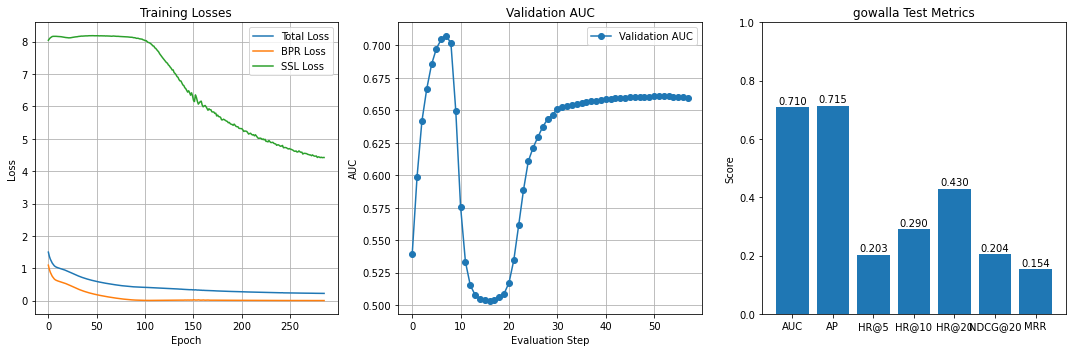

In [16]:
def main_gr_mc():
    """Main function to run GR-MC on gowalla dataset"""

    config = {
        'model_type': 'GRMC',
        'dataset': 'Gowalla',

        'device': torch.device(
            'cuda'
            if torch.cuda.is_available()
            else 'cpu'
        ),

        'hidden_size': 128,
        'num_layers': 3,

        'edge_dropout': 0.1,
        'temperature': 0.2,
        'contrastive_weight': 0.05,
        'reg_weight': 1e-6,

        'learning_rate': 1e-4,
        'epochs': 300,
        'early_stop_patience': 50
    }

    print(
        f"Using device: {config['device']}"
    )

    print("\n" + "=" * 60)
    print("STEP 1: Loading gowalla Dataset")
    print("=" * 60)

    gowalla_path = "./gowalla/gowalla"   # Change if needed

    data, user_feat_dim, item_feat_dim = (
        load_gowalla_dataset(
            gowalla_path,
            use_features=True
        )
    )

    print("\nDataset Statistics:")
    print(f"Users: {data.num_users}")
    print(f"Items: {data.num_items}")
    print(f"Interactions: {data.edge_index.size(1)}")
    print(f"User Feature Dim: {user_feat_dim}")
    print(f"Item Feature Dim: {item_feat_dim}")

    data = data.to(
        config['device']
    )

    print("\n" + "=" * 60)
    print("STEP 2: Training GR-MC Model")
    print("=" * 60)

    start_time = time.time()

    results = train_gr_mc_with_data(
        data,
        config
    )

    end_time = time.time()

    print("\n" + "=" * 60)
    print("FINAL RESULTS - GR-MC")
    print("=" * 60)

    print(
        f"Model: {config['model_type']}"
    )

    print(
        f"Dataset: {config['dataset']}"
    )

    print("\n--- LINK PREDICTION METRICS ---")

    print(
        f"AUC: {results['test_metrics']['AUC']:.4f}"
    )

    print(
        f"AP: {results['test_metrics']['AP']:.4f}"
    )

    print("\n--- RECOMMENDATION METRICS ---")

    print(
        f"HitRatio@5: {results['rec_metrics']['HitRatio@5']:.4f}"
    )

    print(
        f"HitRatio@10: {results['rec_metrics']['HitRatio@10']:.4f}"
    )

    print(
        f"HitRatio@20: {results['rec_metrics']['HitRatio@20']:.4f}"
    )

    print(
        f"NDCG@5: {results['rec_metrics']['NDCG@5']:.4f}"
    )

    print(
        f"NDCG@10: {results['rec_metrics']['NDCG@10']:.4f}"
    )

    print(
        f"NDCG@20: {results['rec_metrics']['NDCG@20']:.4f}"
    )

    print(
        f"MRR: {results['rec_metrics']['MRR']:.4f}"
    )

    print(
        f"Time Taken: {end_time - start_time:.2f} seconds"
    )

    plt.figure(figsize=(15, 5))

    # Training Loss
    plt.subplot(1, 3, 1)

    losses_array = [
        l['total_loss']
        for l in results['losses']
    ]

    plt.plot(
        losses_array,
        label='Total Loss'
    )

    plt.plot(
        [
            l['bpr_loss']
            for l in results['losses']
        ],
        label='BPR Loss'
    )

    plt.plot(
        [
            l['ssl_loss']
            for l in results['losses']
        ],
        label='SSL Loss'
    )

    plt.title('Training Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Validation AUC
    plt.subplot(1, 3, 2)

    plt.plot(
        results['val_aucs'],
        marker='o',
        label='Validation AUC'
    )

    plt.title('Validation AUC')
    plt.xlabel('Evaluation Step')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True)

    # Final Metrics
    plt.subplot(1, 3, 3)

    metrics = [
        'AUC',
        'AP',
        'HR@5',
        'HR@10',
        'HR@20',
        'NDCG@20',
        'MRR'
    ]

    values = [
        results['test_metrics']['AUC'],
        results['test_metrics']['AP'],
        results['rec_metrics']['HitRatio@5'],
        results['rec_metrics']['HitRatio@10'],
        results['rec_metrics']['HitRatio@20'],
        results['rec_metrics']['NDCG@20'],
        results['rec_metrics']['MRR']
    ]

    bars = plt.bar(
        metrics,
        values
    )

    plt.title(
        'gowalla Test Metrics'
    )

    plt.ylabel('Score')
    plt.ylim(0, 1)

    for bar, value in zip(
        bars,
        values
    ):
        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            value + 0.01,
            f'{value:.3f}',
            ha='center'
        )

    plt.tight_layout()
    plt.show()

    return results


if __name__ == '__main__':
    results = main_gr_mc()